SECTION 1 — Setup

In [2]:
!pip install yfinance xgboost pandas numpy matplotlib seaborn scikit-learn tensorflow ta transformers torch shap pandas_datareader feedparser gdeltdoc openai

'pip' is not recognized as an internal or external command,
operable program or batch file.


1-1 Imports

In [3]:
import os
import time
import warnings
from datetime import datetime, timedelta

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from pandas_datareader import data as pdr

from ta.trend import SMAIndicator, EMAIndicator, MACD
from ta.momentum import RSIIndicator
from ta.volatility import BollingerBands

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

from transformers import pipeline

import shap

import feedparser

SECTION 2 — Data Download

2-1 Retry downloader

In [4]:
def download_with_retry(ticker, start, end, max_retries=5, delay=3):
    for attempt in range(max_retries):
        try:
            data = yf.download(
                ticker,
                start=start,
                end=end,
                progress=False,
                auto_adjust=True
            )

            if not data.empty:
                print(f"{ticker} downloaded ({len(data)} rows)")
                return data
            else:
                print(f"{ticker} empty")

        except Exception as e:
            print(f"Error downloading {ticker}: {e}")

        if attempt < max_retries - 1:
            time.sleep(delay)

    return pd.DataFrame()

2-2 Download multi-source data

In [ ]:
start_date = "2006-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")  

tickers = {
    "GC=F": "Gold_Price",
    "SI=F": "Silver_Price",
    "^GSPC": "SP500",
    "CL=F": "Oil_Price",
    "^VIX": "VIX",
    "DX-Y.NYB": "Dollar_Index",
    "^TNX": "US10Y"
}

2-3 Merge all market data

In [6]:
df_combined = None

for ticker, name in tickers.items():
    data = download_with_retry(ticker, start_date, end_date)

    if not data.empty:


        if isinstance(data.columns, pd.MultiIndex):
            close_series = data[("Close", ticker)]
        else:
            close_series = data["Close"]

        close_series = pd.Series(
            close_series.values,
            index=close_series.index,
            name=name
        )

        if df_combined is None:
            df_combined = close_series.to_frame()
        else:
            df_combined = df_combined.join(
                close_series,
                how="outer"
            )

    time.sleep(1)

print("\nFinal shape:", df_combined.shape)
print(df_combined.head())

GC=F downloaded (5165 rows)
SI=F downloaded (5166 rows)
^GSPC downloaded (5166 rows)
CL=F downloaded (5166 rows)
^VIX downloaded (5167 rows)
DX-Y.NYB downloaded (5169 rows)
^TNX downloaded (5163 rows)

Final shape: (5174, 7)
            Gold_Price  Silver_Price        SP500  Oil_Price    VIX  \
Date                                                                  
2006-01-03  530.700012         9.087  1268.800049  63.139999  11.14   
2006-01-04  533.900024         9.102  1273.459961  63.419998  11.37   
2006-01-05  526.299988         8.809  1273.479980  62.790001  11.31   
2006-01-06  539.700012         9.112  1285.449951  64.209999  11.00   
2006-01-09  549.099976         9.222  1290.150024  63.500000  11.13   

            Dollar_Index  US10Y  
Date                             
2006-01-03     89.839996  4.370  
2006-01-04     89.139999  4.356  
2006-01-05     89.330002  4.356  
2006-01-06     88.849998  4.379  
2006-01-09     89.250000  4.379  


2-4 Inflation data

In [7]:
inflation_start = (
    pd.to_datetime(start_date) - pd.DateOffset(months=14)
).strftime("%Y-%m-%d")

inflation = pdr.DataReader(
    "CPIAUCSL",
    "fred",
    inflation_start,
    end_date
)

inflation["Inflation_Rate"] = (
    inflation["CPIAUCSL"].pct_change(12) * 100
)

inflation_daily = inflation["Inflation_Rate"].resample("D").ffill()
df_combined = df_combined.join(inflation_daily, how="left")

2-5 Save dataset

In [8]:
df_combined = df_combined.dropna(how="all")
df_combined.reset_index(inplace=True)
df_combined.rename(columns={"index": "Date"}, inplace=True)

df_combined.to_csv("gold_dataset.csv", index=False)

SECTION 3 — Missing Data Analysis

3-1 Load Dataset

In [9]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("gold_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (5174, 9)


,Date,Gold_Price,Silver_Price,SP500,Oil_Price,VIX,Dollar_Index,US10Y,Inflation_Rate
0,2006-01-03,530.700012,9.087,1268.800049,63.139999,11.14,89.839996,4.370,4.018789
1,2006-01-04,533.900024,9.102,1273.459961,63.419998,11.37,89.139999,4.356,4.018789
2,2006-01-05,526.299988,8.809,1273.479980,62.790001,11.31,89.330002,4.356,4.018789
3,2006-01-06,539.700012,9.112,1285.449951,64.209999,11.00,88.849998,4.379,4.018789
4,2006-01-09,549.099976,9.222,1290.150024,63.500000,11.13,89.250000,4.379,4.018789


3-2 Missing Values Count

In [10]:

missing_counts = df.isnull().sum()

print("\nMISSING VALUES PER COLUMN:")
print(missing_counts)

missing_percent = (df.isnull().sum() / len(df)) * 100

print("\nMISSING PERCENTAGE:")
print(missing_percent)


MISSING VALUES PER COLUMN:
Date               0
Gold_Price         9
Silver_Price       8
SP500              8
Oil_Price          8
VIX                7
Dollar_Index       5
US10Y             11
Inflation_Rate    32
dtype: int64

MISSING PERCENTAGE:
Date              0.000000
Gold_Price        0.173947
Silver_Price      0.154619
SP500             0.154619
Oil_Price         0.154619
VIX               0.135292
Dollar_Index      0.096637
US10Y             0.212601
Inflation_Rate    0.618477
dtype: float64


3-3 Missing Values Heatmap

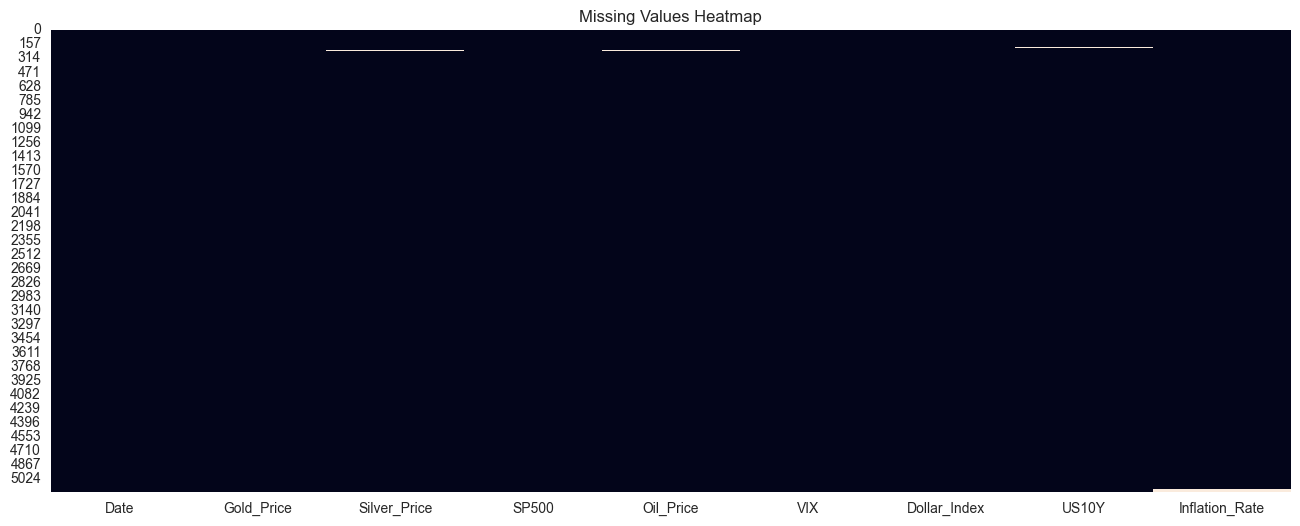

In [11]:

plt.figure(figsize=(16,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

3-4 Detect Missing Dates

In [12]:

full_range = pd.date_range(
    start=df["Date"].min(),
    end=df["Date"].max(),
    freq="D"
)

missing_dates = full_range.difference(df["Date"])

print("Total missing dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("\nSample missing dates:")
    print(missing_dates[:20])

Total missing dates: 2327

Sample missing dates:
DatetimeIndex(['2006-01-07', '2006-01-08', '2006-01-14', '2006-01-15',
               '2006-01-16', '2006-01-21', '2006-01-22', '2006-01-28',
               '2006-01-29', '2006-02-04', '2006-02-05', '2006-02-11',
               '2006-02-12', '2006-02-18', '2006-02-19', '2006-02-20',
               '2006-02-25', '2006-02-26', '2006-03-04', '2006-03-05'],
              dtype='datetime64[ns]', freq=None)


3-5 Consecutive Missing Blocks

In [13]:

for col in df.columns:
    if col != "Date":

        is_nan = df[col].isna()
        groups = (is_nan != is_nan.shift()).cumsum()

        blocks = df[is_nan].groupby(groups)

        for _, block in blocks:
            if len(block) > 3:
                print(f"\nColumn: {col}")
                print(f"Start: {block['Date'].iloc[0]}")
                print(f"End: {block['Date'].iloc[-1]}")
                print(f"Length: {len(block)}")


Column: Inflation_Rate
Start: 2026-06-02 00:00:00
End: 2026-07-17 00:00:00
Length: 32


3-6 Handle Missing Values

In [14]:

df = df.ffill()
before_drop = df.shape[0]
df = df.dropna()
after_drop = df.shape[0]

print(f"Rows dropped (no prior data to forward-fill): {before_drop - after_drop}")
print("Remaining Missing Values:")
print(df.isnull().sum())

Rows dropped (no prior data to forward-fill): 0
Remaining Missing Values:
Date              0
Gold_Price        0
Silver_Price      0
SP500             0
Oil_Price         0
VIX               0
Dollar_Index      0
US10Y             0
Inflation_Rate    0
dtype: int64


SECTION 4 — Exploratory Data Analysis (EDA)

4-1 Basic Information

In [15]:

print(df.info())

print("\nDescriptive Statistics:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5174 entries, 0 to 5173
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            5174 non-null   datetime64[ns]
 1   Gold_Price      5174 non-null   float64       
 2   Silver_Price    5174 non-null   float64       
 3   SP500           5174 non-null   float64       
 4   Oil_Price       5174 non-null   float64       
 5   VIX             5174 non-null   float64       
 6   Dollar_Index    5174 non-null   float64       
 7   US10Y           5174 non-null   float64       
 8   Inflation_Rate  5174 non-null   float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 363.9 KB
None

Descriptive Statistics:
                                Date   Gold_Price  Silver_Price        SP500  \
count                           5174  5174.000000   5174.000000  5174.000000   
mean   2016-04-07 16:07:08.604561152  1570.839485     22.697171  2722.5

4-2 Gold Price Trend

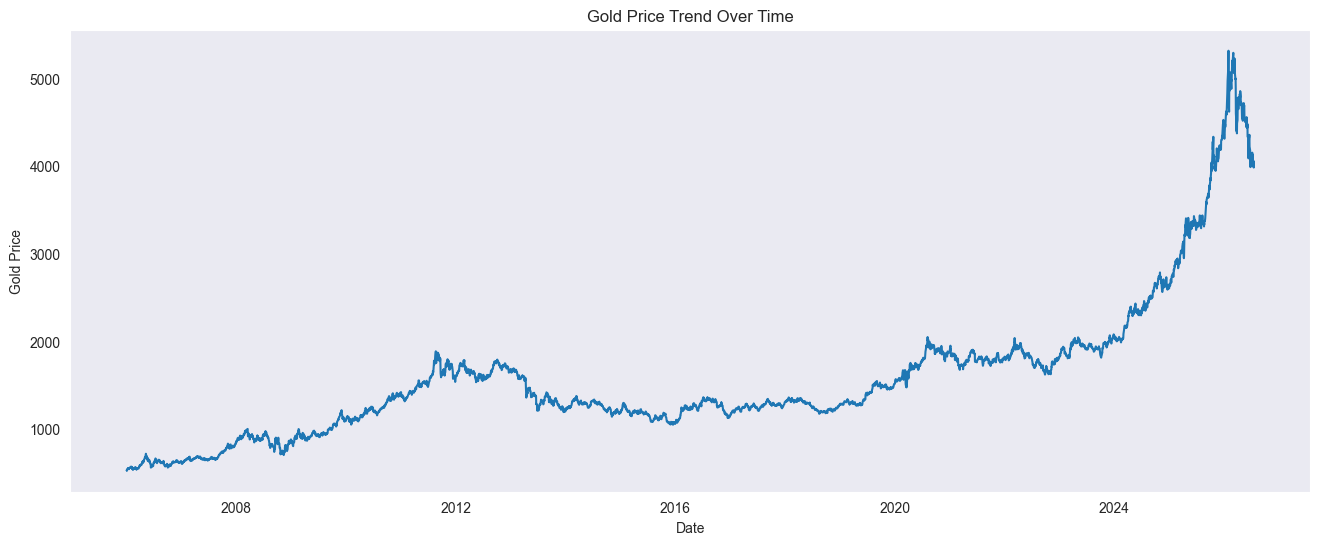

In [16]:

plt.figure(figsize=(16,6))

plt.plot(
    df["Date"],
    df["Gold_Price"]
)

plt.title("Gold Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.grid()
plt.show()

4-3 Daily Returns

In [17]:

df["Gold_Return"] = df["Gold_Price"].pct_change()

print(df["Gold_Return"].describe())

count    5173.000000
mean        0.000460
std         0.011689
min        -0.113662
25%        -0.004954
50%         0.000483
75%         0.006538
max         0.090277
Name: Gold_Return, dtype: float64


4-4 Returns Distribution

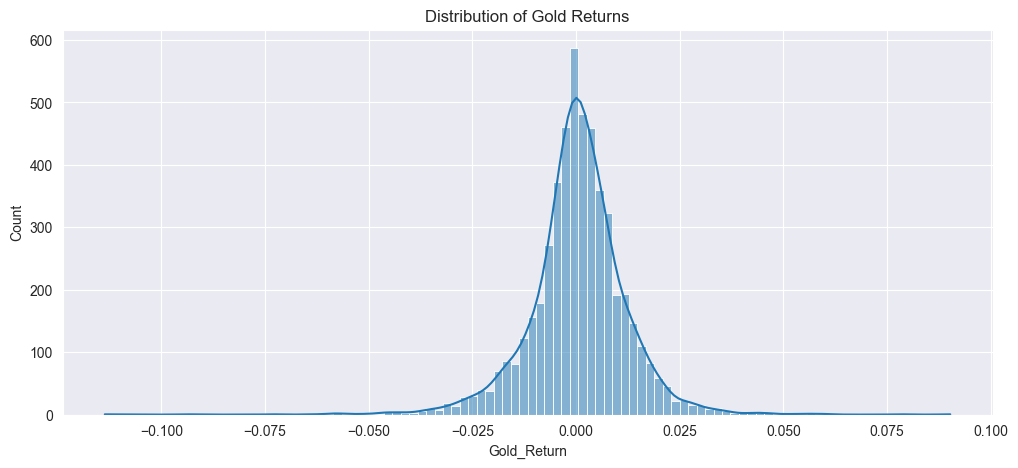

In [18]:

plt.figure(figsize=(12,5))

sns.histplot(
    df["Gold_Return"].dropna(),
    bins=100,
    kde=True
)

plt.title("Distribution of Gold Returns")
plt.show()

4-5 Rolling Volatility (30 Days)

In [19]:

df["Volatility_30"] = (
    df["Gold_Return"]
    .rolling(30)
    .std()
)

4-6 Volatility Plot

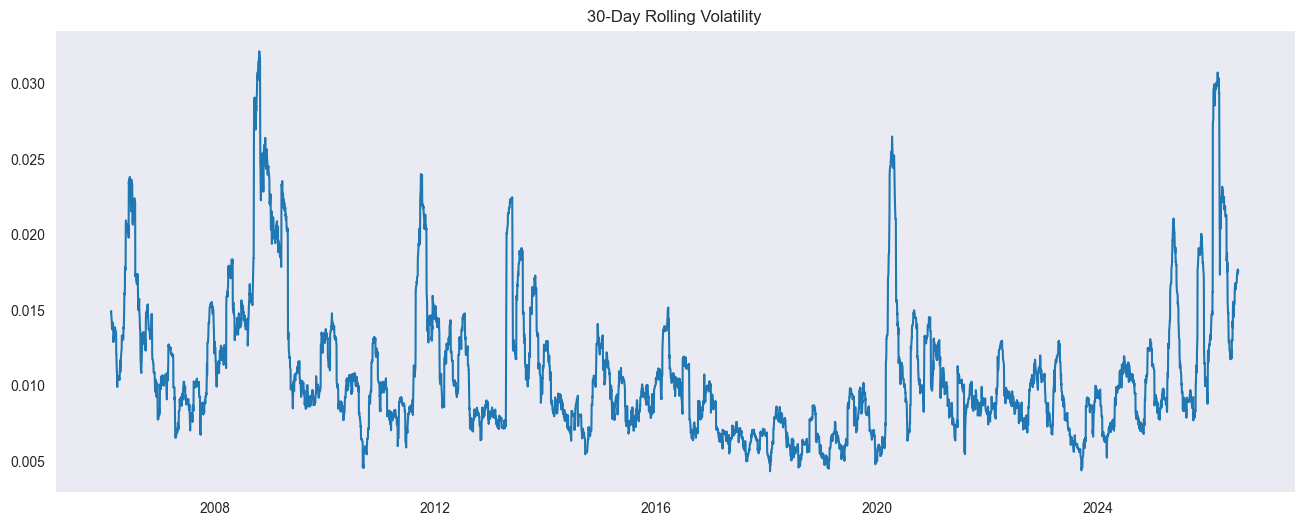

In [20]:

plt.figure(figsize=(16,6))

plt.plot(
    df["Date"],
    df["Volatility_30"]
)

plt.title("30-Day Rolling Volatility")
plt.grid()
plt.show()

4-7 Correlation Matrix

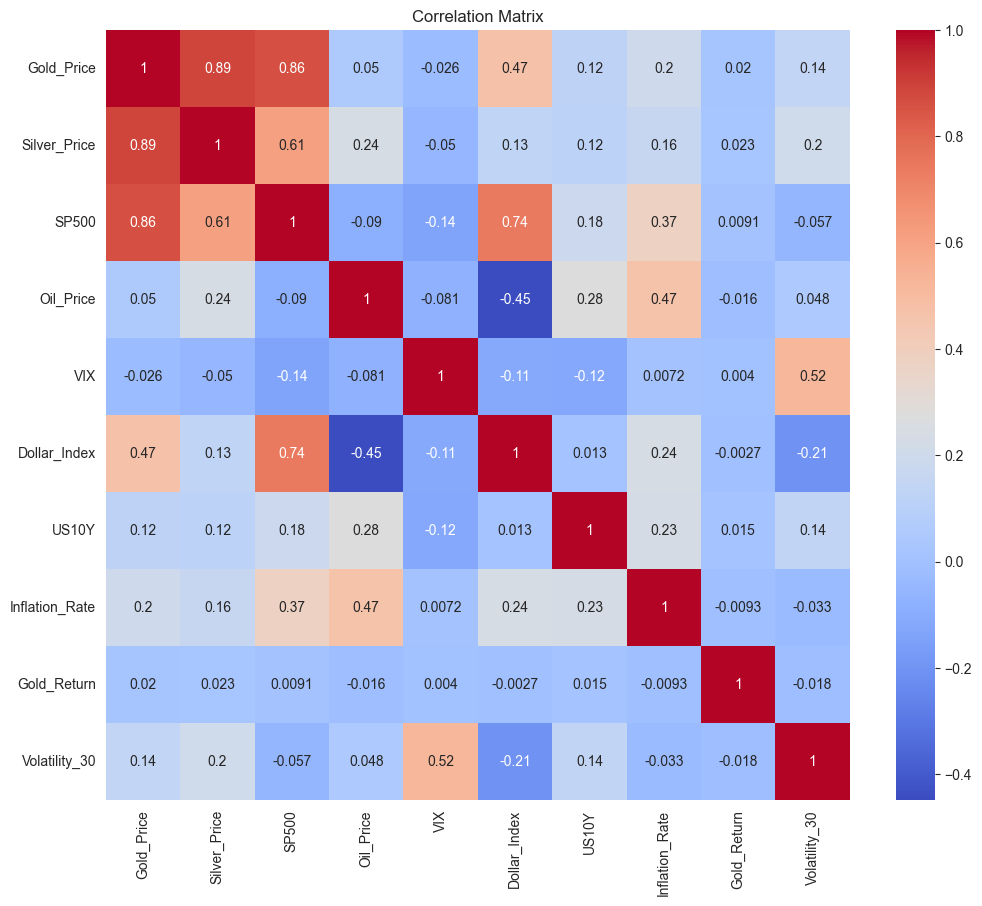

In [21]:

plt.figure(figsize=(12,10))

corr = df.drop(columns=["Date"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

4-8 Selected Feature Trends

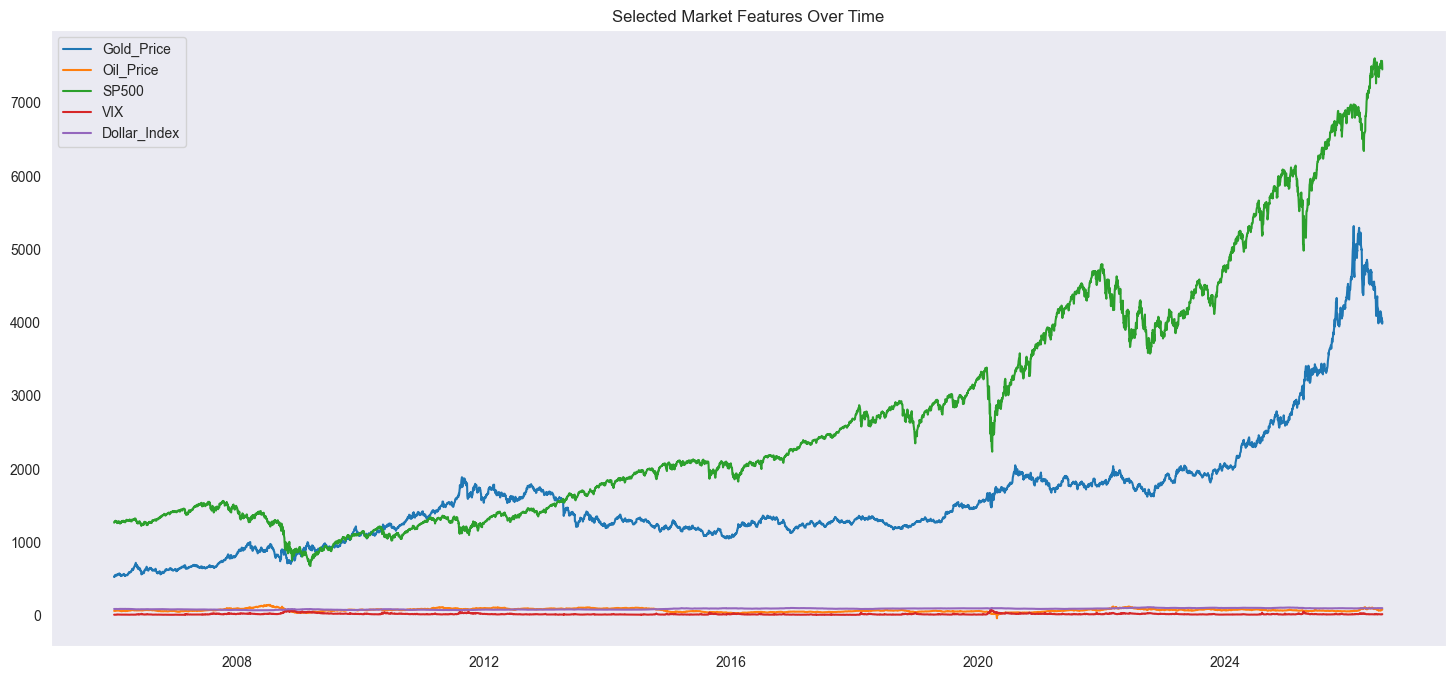

In [22]:
selected_cols = [
    "Gold_Price",
    "Oil_Price",
    "SP500",
    "VIX",
    "Dollar_Index"
]

plt.figure(figsize=(18,8))

for col in selected_cols:
    plt.plot(df["Date"], df[col], label=col)

plt.legend()
plt.title("Selected Market Features Over Time")
plt.grid()
plt.show()

4-9 Boxplot (Outlier Detection)

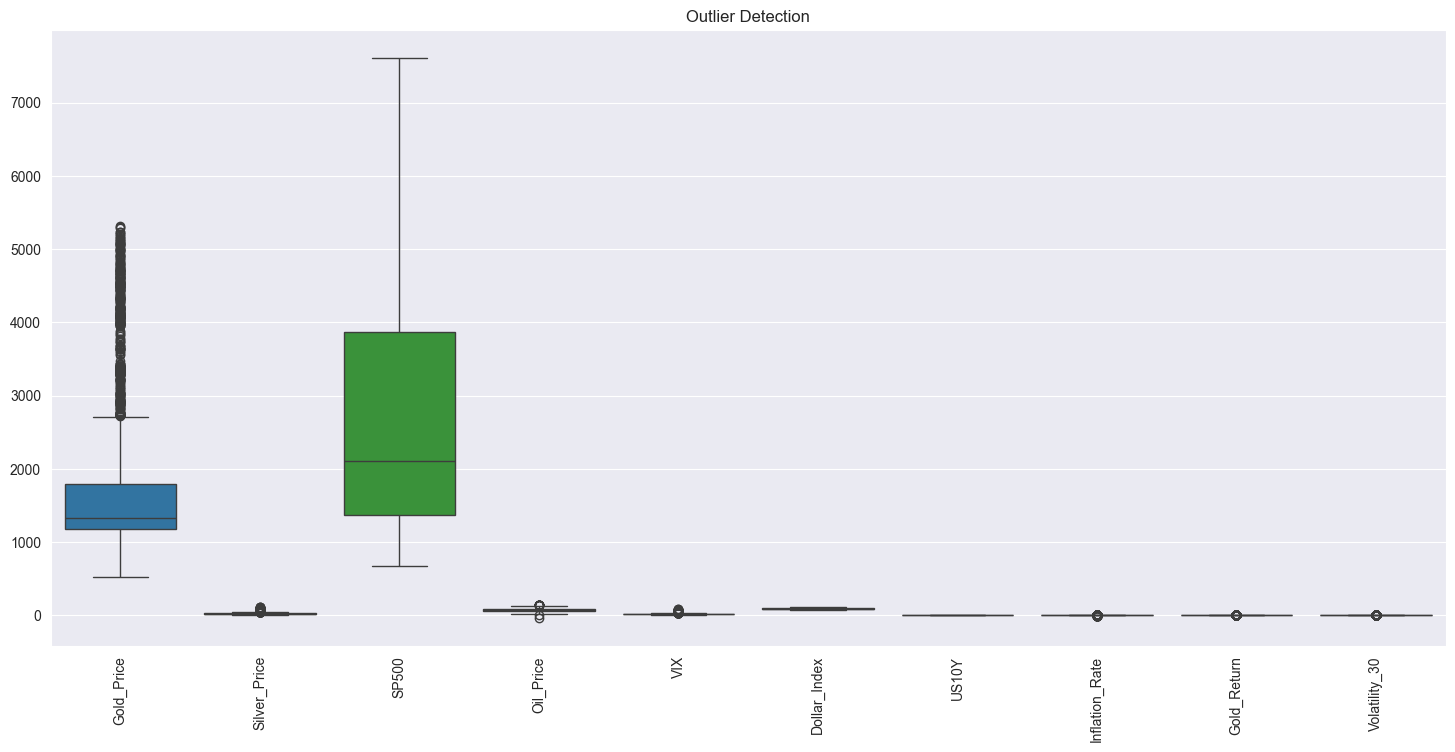

In [23]:
numeric_cols = df.drop(columns=["Date"]).select_dtypes(include=np.number)

plt.figure(figsize=(18,8))

sns.boxplot(data=numeric_cols)

plt.xticks(rotation=90)
plt.title("Outlier Detection")
plt.show()

SECTION 5 — Advanced Feature Engineering

5-1 Simple Moving Averages (SMA)

In [ ]:
from ta.trend import SMAIndicator

df["SMA_7"] = SMAIndicator(
    close=df["Gold_Price"],
    window=7
).sma_indicator()

df["SMA_14"] = SMAIndicator(
    close=df["Gold_Price"],
    window=14
).sma_indicator()

df["SMA_30"] = SMAIndicator(
    close=df["Gold_Price"],
    window=30
).sma_indicator()
df["Gold_MA_7"] = df["Gold_Price"].rolling(7).mean()
df["Gold_MA_30"] = df["Gold_Price"].rolling(30).mean()


df["Gold_Return"] = df["Gold_Price"].pct_change()


df[["Gold_Price","SMA_7","SMA_14","SMA_30","Gold_Price", "Gold_Return"]].tail()

,Gold_Price,SMA_7,SMA_14,SMA_30,Gold_Price,Gold_Return
5169,3997.000000,4102.242885,4075.614293,4208.873348,3997.000000,-0.026096
5170,4061.100098,4094.871443,4070.700021,4192.226685,4061.100098,0.016037
5171,4044.000000,4079.000000,4074.535732,4177.853345,4044.000000,-0.004211
5172,3985.600098,4056.185756,4071.328596,4161.070011,3985.600098,-0.014441
5173,4019.800049,4048.885777,4067.121460,4147.173340,4019.800049,0.008581


5-2 Exponential Moving Average (EMA)

In [25]:
from ta.trend import EMAIndicator

df["EMA_7"] = EMAIndicator(
    close=df["Gold_Price"],
    window=7
).ema_indicator()

df["EMA_14"] = EMAIndicator(
    close=df["Gold_Price"],
    window=14
).ema_indicator()

df[["EMA_7","EMA_14","Gold_MA_7","Gold_MA_30"]].tail()

,EMA_7,EMA_14,Gold_MA_7,Gold_MA_30
5169,4080.300852,4110.303546,4102.242885,4208.873348
5170,4075.500664,4103.743086,4094.871443,4192.226685
5171,4067.625498,4095.777342,4079.000000,4177.853345
5172,4047.119148,4081.087042,4056.185756,4161.070011
5173,4040.289373,4072.915443,4048.885777,4147.173340


5-3 RSI

In [26]:
from ta.momentum import RSIIndicator

df["RSI"] = RSIIndicator(
    close=df["Gold_Price"],
    window=14
).rsi()

df["RSI"].tail()

5169    36.792869
5170    41.924764
5171    40.969127
5172    37.800184
5173    40.693260
Name: RSI, dtype: float64

5-4 MACD

In [27]:
from ta.trend import MACD

macd = MACD(close=df["Gold_Price"])

df["MACD"] = macd.macd()
df["MACD_Signal"] = macd.macd_signal()
df["MACD_Diff"] = macd.macd_diff()

df[["MACD","MACD_Signal","MACD_Diff"]].tail()

,MACD,MACD_Signal,MACD_Diff
5169,-82.094160,-92.832795,10.738635
5170,-79.141038,-90.094444,10.953405
5171,-77.289557,-87.533466,10.243909
5172,-79.616856,-85.950144,6.333289
5173,-77.804722,-84.321060,6.516338


5-5 Bollinger Bands

In [28]:
from ta.volatility import BollingerBands

bb = BollingerBands(
    close=df["Gold_Price"],
    window=20
)

df["BB_High"] = bb.bollinger_hband()
df["BB_Low"] = bb.bollinger_lband()
df["BB_Mid"] = bb.bollinger_mavg()

df[["BB_High","BB_Low","BB_Mid"]].tail()

,BB_High,BB_Low,BB_Mid
5169,4350.369425,3919.370565,4134.869995
5170,4341.668330,3912.681670,4127.175000
5171,4309.235818,3916.714182,4112.975000
5172,4271.984255,3919.435764,4095.710010
5173,4209.985360,3947.524674,4078.755017


5-6 Create Lag Features

In [29]:
df["Gold_Lag_1"] = df["Gold_Price"].shift(1)
df["Gold_Lag_3"] = df["Gold_Price"].shift(3)
df["Gold_Lag_7"] = df["Gold_Price"].shift(7)

df[[
    "Gold_Lag_1",
    "Gold_Lag_3",
    "Gold_Lag_7"
]].head(10)

,Gold_Lag_1,Gold_Lag_3,Gold_Lag_7
0,NaN,NaN,NaN
1,530.700012,NaN,NaN
2,533.900024,NaN,NaN
3,526.299988,530.700012,NaN
4,539.700012,533.900024,NaN
5,549.099976,526.299988,NaN
6,544.299988,539.700012,NaN
7,548.799988,549.099976,530.700012
8,548.299988,544.299988,533.900024
9,556.099976,548.799988,526.299988


5-7 Price Change Features

In [30]:
df["Delta_1"] = df["Gold_Price"] - df["Gold_Lag_1"]
df["Delta_3"] = df["Gold_Price"] - df["Gold_Lag_3"]
df["Delta_7"] = df["Gold_Price"] - df["Gold_Lag_7"]

df[["Delta_1","Delta_3","Delta_7"]].tail()

,Delta_1,Delta_3,Delta_7
5169,-107.100098,-73.899902,-71.300049
5170,64.100098,-69.500000,-51.600098
5171,-17.100098,-60.100098,-111.100098
5172,-58.399902,-11.399902,-159.699707
5173,34.199951,-41.300049,-51.099854


5-8 Rolling Mean / Std

In [31]:
df["Rolling_Mean_7"] = (
    df["Gold_Price"]
    .rolling(7)
    .mean()
)

df["Rolling_STD_7"] = (
    df["Gold_Price"]
    .rolling(7)
    .std()
)

df["Rolling_Mean_30"] = (
    df["Gold_Price"]
    .rolling(30)
    .mean()
)

df["Rolling_STD_30"] = (
    df["Gold_Price"]
    .rolling(30)
    .std()
)


df["Gold_Volatility_30"] = (
    df["Gold_Return"]
    .rolling(30)
    .std()
)

df[[
    "Rolling_Mean_7",
    "Rolling_STD_7",
    "Rolling_Mean_30",
    "Rolling_STD_30",
    "Gold_Volatility_30"
]].tail()

,Rolling_Mean_7,Rolling_STD_7,Rolling_Mean_30,Rolling_STD_30,Gold_Volatility_30
5169,4102.242885,54.195890,4208.873348,165.817678,0.017598
5170,4094.871443,56.015137,4192.226685,153.942651,0.017686
5171,4079.000000,51.677312,4177.853345,146.564239,0.017459
5172,4056.185756,52.769494,4161.070011,138.288500,0.017533
5173,4048.885777,53.916761,4147.173340,130.354854,0.017610


5-9 Note on Target Variable

In [32]:
print("Target will be defined in Section 7-1.")

Target will be defined in Section 7-1.


5-10 Final Cleaning

In [33]:
before = df.shape[0]

df.dropna(inplace=True)

after = df.shape[0]

print("Rows before:", before)
print("Rows after:", after)
print("Rows removed:", before - after)

Rows before: 5174
Rows after: 5141
Rows removed: 33


In [34]:
feature_check = [
    "Gold_Price",
    "Gold_Return",
    "Gold_MA_7",
    "Gold_MA_30",
    "Gold_Volatility_30"
]

print(df[feature_check].corr())

                    Gold_Price  Gold_Return  Gold_MA_7  Gold_MA_30  \
Gold_Price            1.000000     0.020456   0.999241    0.996732   
Gold_Return           0.020456     1.000000  -0.000115   -0.001287   
Gold_MA_7             0.999241    -0.000115   1.000000    0.998030   
Gold_MA_30            0.996732    -0.001287   0.998030    1.000000   
Gold_Volatility_30    0.142955    -0.018088   0.145568    0.149166   

                    Gold_Volatility_30  
Gold_Price                    0.142955  
Gold_Return                  -0.018088  
Gold_MA_7                     0.145568  
Gold_MA_30                    0.149166  
Gold_Volatility_30            1.000000  


SECTION 6 — News Pipeline (FinBERT + Sentiment Scoring)

6-1 Fetch Gold Related News

In [39]:
import feedparser
import pandas as pd
from datetime import datetime


def fetch_economic_news(days=90):

    queries = [
        "gold price",
        "gold market",
        "interest rate",
        "inflation",
        "federal reserve",
        "geopolitics economy",
        "usd dollar strength"
    ]

    news_list = []

    for q in queries:

        rss_url = (
            f"https://news.google.com/rss/search?"
            f"q={q.replace(' ', '+')}"
            "&hl=en-US&gl=US&ceid=US:en"
        )

        feed = feedparser.parse(rss_url)

        for entry in feed.entries[:20]:

            if "published_parsed" in entry:

                pub_date = datetime(*entry.published_parsed[:6])

                if (datetime.now() - pub_date).days <= days:

                    news_list.append({
                        "Date": pub_date.date(),
                        "Headline": entry.title,
                        "Summary": entry.get("summary", ""),
                        "Link": entry.link
                    })

    news_df = pd.DataFrame(news_list)

    news_df.drop_duplicates(
        subset=["Headline"],
        inplace=True
    )

    news_df["Date"] = pd.to_datetime(news_df["Date"])

    news_df.to_csv(
        "economic_news.csv",
        index=False
    )

    print(f"Collected {len(news_df)} unique news articles")

    return news_df


news_df = fetch_economic_news(days=90)

news_df.head()

Collected 127 unique news articles


,Date,Headline,Summary,Link
0,2026-07-17,"Hormuz Escalation Pressures Gold as $4,000 Sup...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMijAFBV...
1,2026-07-16,"The price of gold today, July 16, 2026 — and t...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMic0FVX...
2,2026-07-17,"Current price of gold: Month Day, Year - Fortune","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMibkFVX...
3,2026-07-16,"Gold prices today, Thursday, July 16, 2026: Pr...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMi7AFBV...
4,2026-07-16,"Gold prices can go lower, but Bank of America ...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiuAFBV...


6-2 Load FinBERT

In [40]:
from transformers import pipeline

finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)

print("FinBERT loaded successfully.")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 23833.97it/s]


FinBERT loaded successfully.


6-3 Score News

In [41]:
sentiment_scores = []
sentiment_labels = []

for _, row in news_df.iterrows():

    full_text = row["Headline"] + " " + str(row["Summary"])

    result = finbert(full_text[:512])[0]

    label = result["label"]
    score = result["score"]

    if label.lower() == "positive":
        impact = score
    elif label.lower() == "negative":
        impact = -score
    else:
        impact = 0

    sentiment_scores.append(impact)
    sentiment_labels.append(label)

news_df["Sentiment_Label"] = sentiment_labels
news_df["Impact_Score"] = sentiment_scores

news_df.head()

,Date,Headline,Summary,Link,Sentiment_Label,Impact_Score
0,2026-07-17,"Hormuz Escalation Pressures Gold as $4,000 Sup...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMijAFBV...,positive,0.479572
1,2026-07-16,"The price of gold today, July 16, 2026 — and t...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMic0FVX...,neutral,0.000000
2,2026-07-17,"Current price of gold: Month Day, Year - Fortune","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMibkFVX...,neutral,0.000000
3,2026-07-16,"Gold prices today, Thursday, July 16, 2026: Pr...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMi7AFBV...,neutral,0.000000
4,2026-07-16,"Gold prices can go lower, but Bank of America ...","<a href=""https://news.google.com/rss/articles/...",https://news.google.com/rss/articles/CBMiuAFBV...,negative,-0.838696


6-4 Daily Sentiment Aggregation

In [42]:
daily_sentiment = (
    news_df.groupby("Date")["Impact_Score"]
    .mean()
    .reset_index()
)

daily_sentiment.head()

,Date,Impact_Score
0,2026-04-23,0.000000
1,2026-05-11,0.000000
2,2026-05-13,0.000000
3,2026-05-14,0.000000
4,2026-05-20,0.930888


6-5 Merge with Main Dataset

In [43]:
df = df.merge(
    daily_sentiment,
    on="Date",
    how="left"
)

df.rename(
    columns={"Impact_Score": "Sentiment_Score"},
    inplace=True
)

df["Sentiment_Has_Data"] = df["Sentiment_Score"].notna()
df["Sentiment_Score"] = df["Sentiment_Score"].fillna(0)

coverage_pct = df["Sentiment_Has_Data"].mean()
print(f"News coverage across price history: {coverage_pct:.1%} of days have real sentiment data.")
print(df.shape)

df[[
    "Date",
    "Gold_Price",
    "Sentiment_Score",
    "Sentiment_Has_Data"
]].tail()

News coverage across price history: 0.4% of days have real sentiment data.
(5141, 38)


,Date,Gold_Price,Sentiment_Score,Sentiment_Has_Data
5136,2026-07-13,3997.000000,0.013002,True
5137,2026-07-14,4061.100098,0.023886,True
5138,2026-07-15,4044.000000,0.039554,True
5139,2026-07-16,3985.600098,-0.239480,True
5140,2026-07-17,4019.800049,-0.057734,True


6-6 Sentiment Distribution

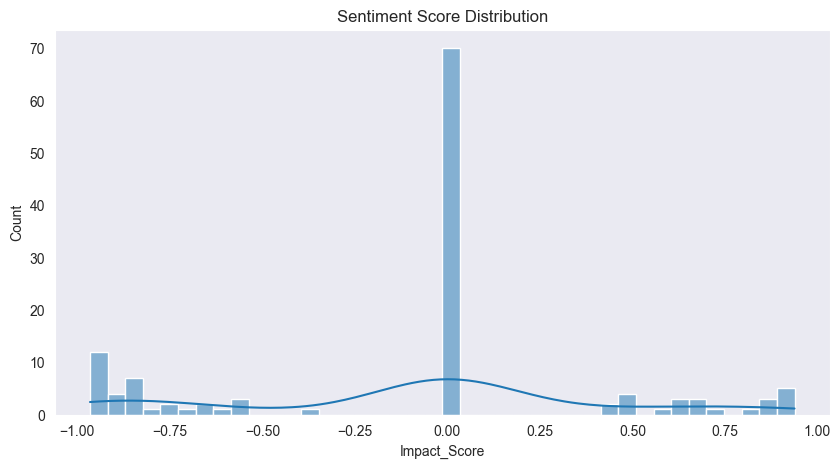

In [44]:
plt.figure(figsize=(10,5))

sns.histplot(
    news_df["Impact_Score"],
    bins=40,
    kde=True
)

plt.title("Sentiment Score Distribution")
plt.grid()
plt.show()

SECTION 7 — Feature Selection + Train/Test Split + Scaling

7-1 Create Target Variable

In [45]:
df["Target"] = df["Gold_Return"].shift(-1)

print(df[["Date", "Gold_Price", "Target"]].tail())

           Date   Gold_Price    Target
5136 2026-07-13  3997.000000  0.016037
5137 2026-07-14  4061.100098 -0.004211
5138 2026-07-15  4044.000000 -0.014441
5139 2026-07-16  3985.600098  0.008581
5140 2026-07-17  4019.800049       NaN


7-2 Remove Last Row

In [46]:
df = df.dropna(subset=["Target"])

print(df.shape)

(5140, 39)


7-3 Feature Selection

In [47]:
feature_cols = [
    "Silver_Price",
    "SP500",
    "Oil_Price",
    "VIX",
    "Inflation_Rate",
    "Sentiment_Score",

    "Gold_Return",
    "Gold_MA_7",
    "Gold_MA_30",
    "Gold_Volatility_30",

    "Gold_Lag_1",
    "Gold_Lag_3",
    "Gold_Lag_7"
]

X = df[feature_cols]
y = df["Target"]

print(X.shape)

(5140, 13)


7-4 Feature Preview

In [48]:
print(X.head())
print("\nColumns:")
print(X.columns.tolist())

   Silver_Price        SP500  Oil_Price    VIX  Inflation_Rate  \
0         9.536  1283.030029  61.099998  12.41        3.638254   
1         9.567  1292.670044  61.009998  11.88        3.638254   
2         9.462  1287.790039  60.540001  11.87        3.638254   
3         9.733  1289.430054  62.910000  11.46        3.638254   
4         9.602  1294.119995  61.000000  11.59        3.638254   

   Sentiment_Score  Gold_Return   Gold_MA_7  Gold_MA_30  Gold_Volatility_30  \
0              0.0     0.003806  546.642866  555.346670            0.014069   
1              0.0     0.000000  547.171439  555.506671            0.013721   
2              0.0    -0.009930  548.514300  555.643339            0.013750   
3              0.0     0.018964  550.357152  555.976672            0.014097   
4              0.0    -0.007337  552.500009  556.190007            0.014171   

   Gold_Lag_1  Gold_Lag_3  Gold_Lag_7  
0  551.799988  539.700012  564.500000  
1  553.900024  546.000000  550.200012  
2  553.9

7-5 Time-based Train/Test Split

In [49]:
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4112, 13)
X_test: (1028, 13)
y_train: (4112,)
y_test: (1028,)


7-6 Plot Train/Test Split

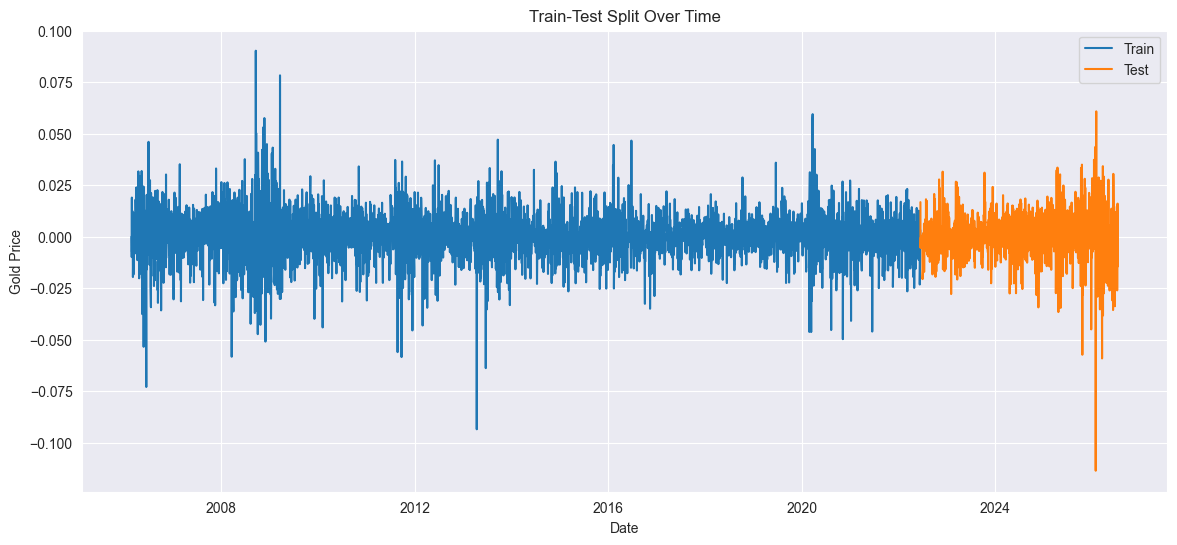

In [50]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"].iloc[:split_index],
    y_train,
    label="Train"
)

plt.plot(
    df["Date"].iloc[split_index:],
    y_test,
    label="Test"
)

plt.title("Train-Test Split Over Time")
plt.xlabel("Date")
plt.ylabel("Gold Price")
plt.legend()
plt.grid(True)
plt.show()

7-7 Feature Scaling

In [51]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")
print("Mean:", X_train_scaled.mean())
print("Std:", X_train_scaled.std())

Scaling completed.
Mean: 6.805557481090454e-17
Std: 0.9607689228305228


SECTION 8 — Hyperparameter Tuning + TimeSeriesSplit + XGBoost

8-1 Define TimeSeriesSplit

In [52]:
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import GridSearchCV
tscv = TimeSeriesSplit(n_splits=5)
print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)


8-2 Initialize Base Model

In [53]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

print(param_grid)

{'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.8, 1.0]}


8-3 Grid Search with TimeSeriesSplit

In [54]:
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train_scaled,
    y_train
)
print("Best Parameters:")
print(grid_search.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}


In [55]:
best_model = grid_search.best_estimator_

print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)


SECTION 9 — Held-out Test Evaluation + Residual Analysis + Feature Importance

9-1 Predict on Test Set

In [56]:
y_pred = best_model.predict(X_test_scaled)

print("Prediction shape:", y_pred.shape)
print(y_pred[:5])

Prediction shape: (1028,)
[0.0002843  0.00031189 0.00045263 0.00033647 0.00033647]


9-2 Model Evaluation Metrics(MAE/RMSE/R²)

In [57]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

rmse = mean_squared_error(
    y_test,
    y_pred
) ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 0.009238854348995568
RMSE: 0.012789129389942502
R² Score: -0.10586674050160982


9-3 Actual vs Predicted

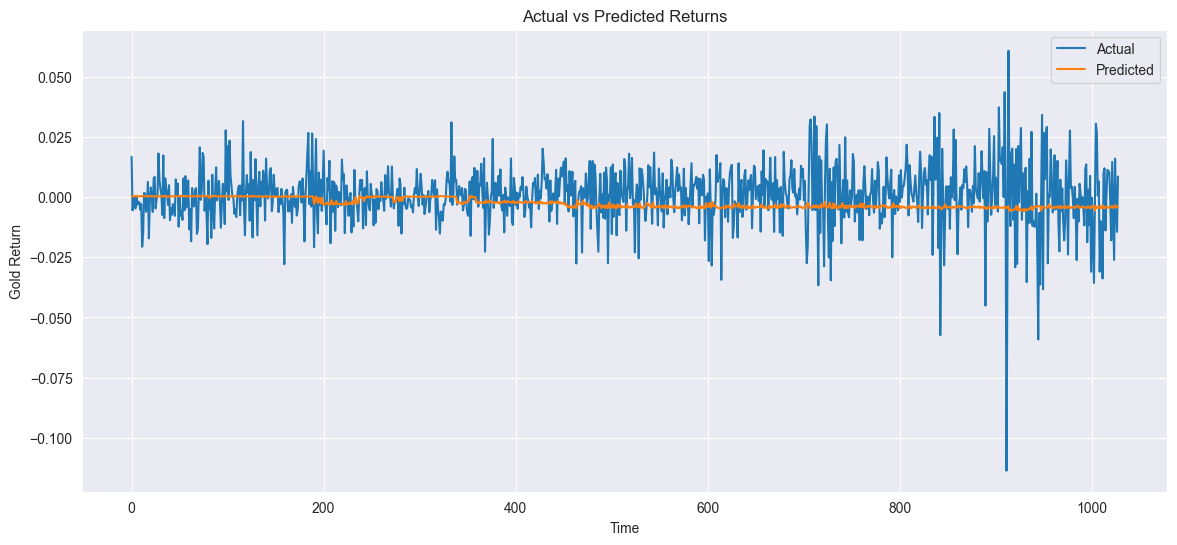

In [58]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Predicted"
)

plt.title("Actual vs Predicted Returns")
plt.xlabel("Time")
plt.ylabel("Gold Return")
plt.legend()
plt.grid(True)
plt.show()

9-4 Residuals

In [59]:
residuals = y_test.values - y_pred

print(residuals[:10])

[ 1.64621919e-02 -5.78405495e-03 -9.97414952e-04 -4.99951217e-04
 -5.02495787e-03  7.48886815e-07 -3.37462228e-03 -2.17588438e-03
 -2.39947339e-03 -5.60169652e-03]


9-5 Residual Distribution

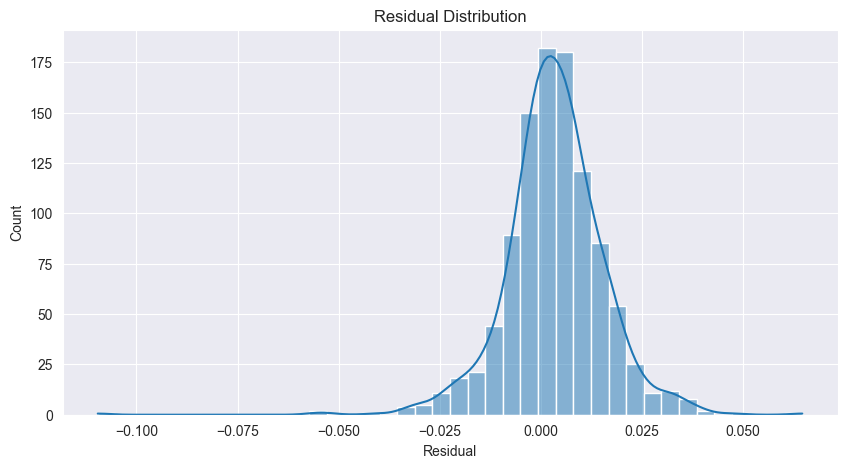

In [60]:
plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    bins=40,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.grid(True)
plt.show()

9-6  Residual Scatter Plot

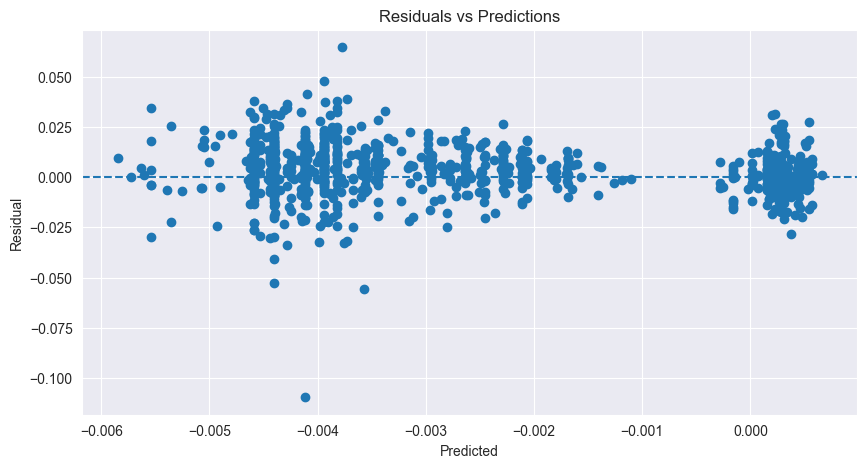

In [61]:
plt.figure(figsize=(10,5))

plt.scatter(
    y_pred,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Residuals vs Predictions")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

9-7 Feature Importance

In [62]:
trained_feature_cols = X_train.columns.tolist()

importance = best_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": trained_feature_cols,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df)

               Feature  Importance
3                  VIX    0.114784
2            Oil_Price    0.098270
12          Gold_Lag_7    0.094981
9   Gold_Volatility_30    0.091843
1                SP500    0.089440
8           Gold_MA_30    0.082015
11          Gold_Lag_3    0.075362
4       Inflation_Rate    0.072329
10          Gold_Lag_1    0.072234
0         Silver_Price    0.072002
6          Gold_Return    0.071511
7            Gold_MA_7    0.065228
5      Sentiment_Score    0.000000


9-8 Plot Feature Importance

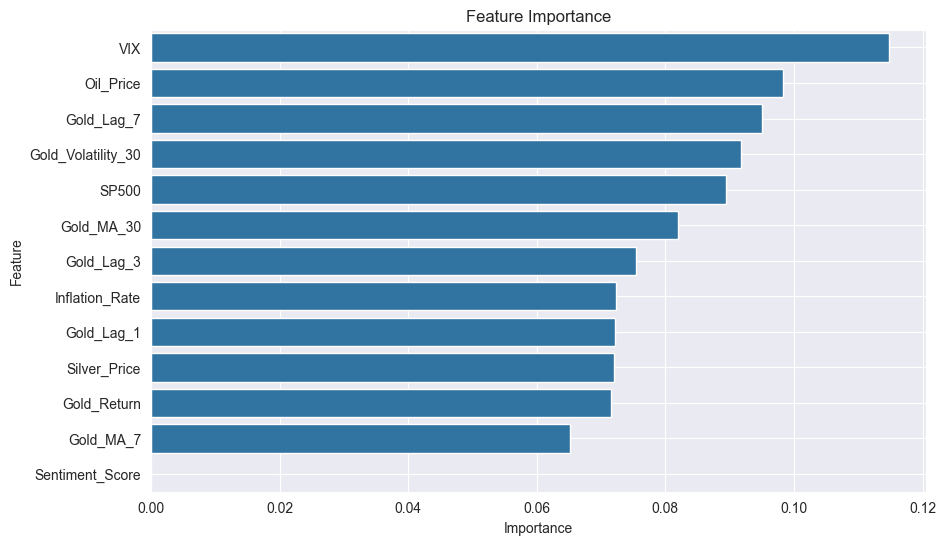

In [63]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.grid(True)
plt.show()

9-9 SHAP Explainability 

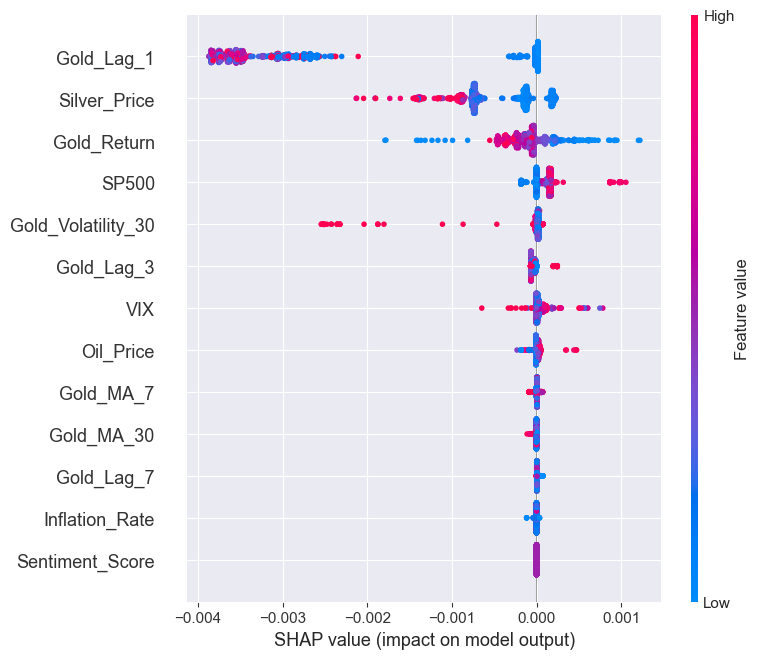

In [64]:
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=trained_feature_cols,
    show=True
)

SECTION 10 — Natural Language Explanation Generator

10-1 Prepare Latest Observation

In [65]:
latest_X = X.iloc[[-1]]

latest_X_scaled = scaler.transform(latest_X)

latest_prediction = best_model.predict(latest_X_scaled)[0]

print("Predicted next-day return:", latest_prediction)

Predicted next-day return: -0.0040711695


10-2 Get Top Important Features

In [66]:
top_features = feature_importance_df.head(3)

print(top_features)

       Feature  Importance
3          VIX    0.114784
2    Oil_Price    0.098270
12  Gold_Lag_7    0.094981


10-3 Interpret Latest Sentiment

In [67]:
sentiment_cols = df.loc[:, df.columns == "Sentiment_Score"]

latest_sentiment = sentiment_cols.iloc[-1, 0]

if latest_sentiment > 0.2:
    sentiment_text = "positive"
elif latest_sentiment < -0.2:
    sentiment_text = "negative"
else:
    sentiment_text = "neutral"

print("Latest sentiment score:", latest_sentiment)
print("Latest sentiment:", sentiment_text)

Latest sentiment score: -0.23947995475360326
Latest sentiment: negative


10-4 Generate Natural Language Explanation

In [68]:
pred_percent = latest_prediction * 100

direction = "increase" if latest_prediction > 0 else "decrease"

top_feature_names = top_features["Feature"].tolist()

explanation = f"""
Gold is expected to {direction} tomorrow by approximately {abs(pred_percent):.2f}%.

The strongest contributing factors in the prediction are:
1. {top_feature_names[0]}
2. {top_feature_names[1]}
3. {top_feature_names[2]}

Current market sentiment based on financial news is {sentiment_text}.
"""

print(explanation)


Gold is expected to decrease tomorrow by approximately 0.41%.

The strongest contributing factors in the prediction are:
1. VIX
2. Oil_Price
3. Gold_Lag_7

Current market sentiment based on financial news is negative.



10-5 Save Final Report

In [69]:
with open("gold_prediction_report.txt", "w", encoding="utf-8") as f:
    f.write(explanation)

print("Report saved successfully.")

Report saved successfully.


SECTION 11 — Sequence Preparation

In [70]:
sequence_df = df[["Gold_Price", "Sentiment_Score"]].copy()
sequence_df = sequence_df.loc[:, ~sequence_df.columns.duplicated()]

window_size = 30
split_ratio = 0.8
split_idx = int(len(sequence_df) * split_ratio)

train_raw = sequence_df.iloc[:split_idx]

test_raw = sequence_df.iloc[split_idx - window_size:]

seq_scaler = MinMaxScaler()
seq_scaler.fit(train_raw)

train_scaled = seq_scaler.transform(train_raw)
test_scaled = seq_scaler.transform(test_raw)

def make_windows(scaled_array, window_size):
    X, y = [], []
    for i in range(window_size, len(scaled_array)):
        X.append(scaled_array[i-window_size:i])
        y.append(scaled_array[i, 0])
    return np.array(X), np.array(y)

X_train_seq, y_train_seq = make_windows(train_scaled, window_size)
X_test_seq, y_test_seq = make_windows(test_scaled, window_size)

X_seq = np.concatenate([X_train_seq, X_test_seq], axis=0)

print("X_train_seq:", X_train_seq.shape, "X_test_seq:", X_test_seq.shape)

X_train_seq: (4082, 30, 2) X_test_seq: (1028, 30, 2)


SECTION 12 — Train/Test Split for LSTM

In [71]:
print("Train sequences:", X_train_seq.shape, y_train_seq.shape)
print("Test sequences:", X_test_seq.shape, y_test_seq.shape)

Train sequences: (4082, 30, 2) (4082,)
Test sequences: (1028, 30, 2) (1028,)


SECTION 13 — Build LSTM Model

In [72]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([

    LSTM(
        64,
        return_sequences=True,
        input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])
    ),

    Dropout(0.2),

    LSTM(32),

    Dropout(0.2),

    Dense(16, activation="relu"),

    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

SECTION 14 — Train LSTM

In [73]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0146 - val_loss: 0.0026
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0027 - val_loss: 0.0020
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0023 - val_loss: 0.0047
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0019 - val_loss: 0.0027
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.0019 - val_loss: 0.0123
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0017 - val_loss: 0.0028
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0014 - val_loss: 0.0052
Epoch 8/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0013 - val_loss: 0.0052
Epoch 9/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0012 - val_loss: 0.0027
Epoch 10/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.0011 - val_loss: 0.0029
Epoch 11/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0011 - val_loss: 0.0037
Epoch 12/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 

SECTION 15 — Predict + Evaluate

In [74]:
y_pred_lstm = lstm_model.predict(X_test_seq)

mae_lstm_scaled = mean_absolute_error(y_test_seq, y_pred_lstm)
rmse_lstm_scaled = np.sqrt(mean_squared_error(y_test_seq, y_pred_lstm))
r2_lstm = r2_score(y_test_seq, y_pred_lstm)

print("LSTM MAE (scaled space):", mae_lstm_scaled)
print("LSTM RMSE (scaled space):", rmse_lstm_scaled)
print("LSTM R²:", r2_lstm)

def inverse_price(scaled_price_col):
    dummy = np.zeros((len(scaled_price_col), 2))
    dummy[:, 0] = scaled_price_col
    return seq_scaler.inverse_transform(dummy)[:, 0]

actual_prices_test = inverse_price(y_test_seq)
pred_prices_test = inverse_price(y_pred_lstm.flatten())


actual_returns_test = (actual_prices_test[1:] - actual_prices_test[:-1]) / actual_prices_test[:-1]
implied_pred_returns_test = (pred_prices_test[1:] - actual_prices_test[:-1]) / actual_prices_test[:-1]

rmse_lstm_return = np.sqrt(mean_squared_error(actual_returns_test, implied_pred_returns_test))
mae_lstm_return = mean_absolute_error(actual_returns_test, implied_pred_returns_test)

print("LSTM MAE (implied daily return):", mae_lstm_return)
print("LSTM RMSE (implied daily return):", rmse_lstm_return)
print("(For comparison, XGBoost return-model RMSE:", rmse, ")")

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
LSTM MAE (scaled space): 0.22466498112283523
LSTM RMSE (scaled space): 0.30309891025299224
LSTM R²: 0.7903826941072507
LSTM MAE (implied daily return): 0.10328617823711693
LSTM RMSE (implied daily return): 0.11888376109709728
(For comparison, XGBoost return-model RMSE: 0.012789129389942502 )


SECTION 16 — Plot Actual vs Predicted

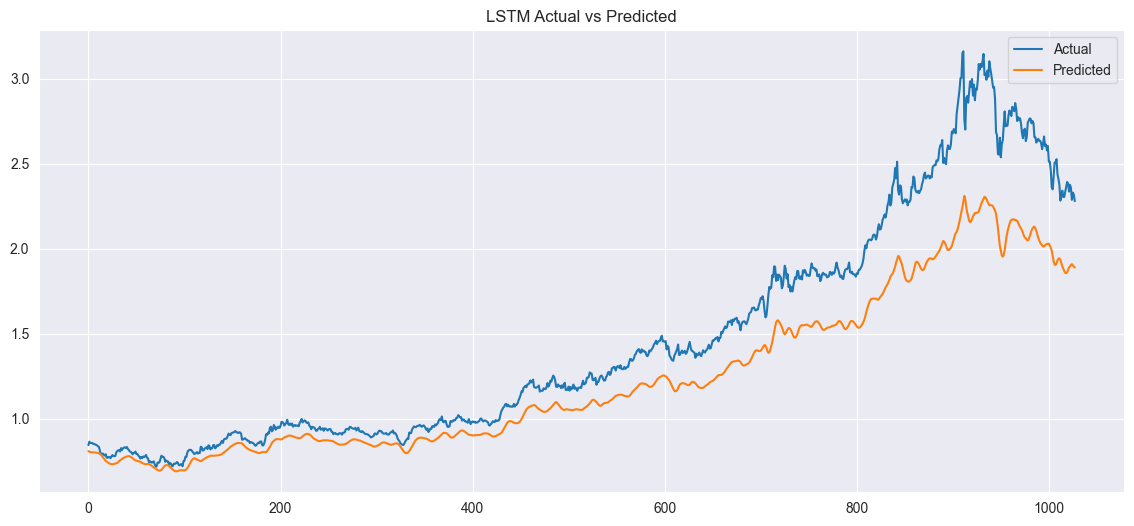

In [75]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test_seq,
    label="Actual"
)

plt.plot(
    y_pred_lstm,
    label="Predicted"
)

plt.title("LSTM Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()

17 — LSTM-Only Next-Day Prediction (diagnostic)



In [76]:
latest_seq = X_seq[-1].reshape(1, X_seq.shape[1], X_seq.shape[2])

future_pred_scaled = lstm_model.predict(latest_seq, verbose=0)[0][0]

last_gold_price = df["Gold_Price"].iloc[-1]

predicted_price_lstm = inverse_price(np.array([future_pred_scaled]))[0]

lstm_direction = "increase" if predicted_price_lstm > last_gold_price else "decrease"

print(f"[LSTM-only, diagnostic] Current price: {last_gold_price:.2f}")
print(f"[LSTM-only, diagnostic] Predicted next-day price: {predicted_price_lstm:.2f} ({lstm_direction})")

[LSTM-only, diagnostic] Current price: 3985.60
[LSTM-only, diagnostic] Predicted next-day price: 3394.47 (decrease)


18 — 10-Day Iterative Forecast (naive extrapolation)


10-Day Iterative Forecast (naive, constant-sentiment assumption)
Current Gold Price: 3985.60
Predicted Price after 10 days: 2132.66
Expected direction: decrease, net change: 1852.94


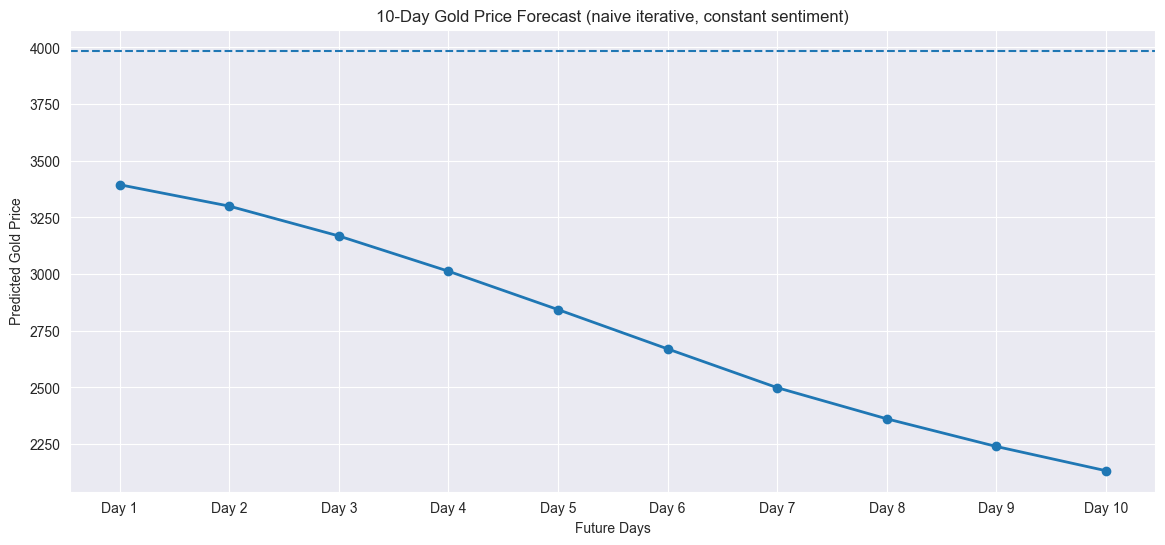

In [77]:
future_days = 10

last_sequence = X_seq[-1].copy()
last_known_sentiment_scaled = last_sequence[-1, 1]

future_predictions = []

for _ in range(future_days):
    pred = lstm_model.predict(
        last_sequence.reshape(1, window_size, 2),
        verbose=0
    )[0][0]

    future_predictions.append(pred)

    new_row = last_sequence[-1].copy()
    new_row[0] = pred
    new_row[1] = last_known_sentiment_scaled

    last_sequence = np.vstack([last_sequence[1:], new_row])

future_prices = inverse_price(np.array(future_predictions))

current_price = df["Gold_Price"].iloc[-1]
price_change = future_prices[-1] - current_price
direction = "increase" if price_change > 0 else "decrease"

print(f"10-Day Iterative Forecast (naive, constant-sentiment assumption)")
print(f"Current Gold Price: {current_price:.2f}")
print(f"Predicted Price after 10 days: {future_prices[-1]:.2f}")
print(f"Expected direction: {direction}, net change: {abs(price_change):.2f}")

forecast_days = [f"Day {i}" for i in range(1, future_days + 1)]

plt.figure(figsize=(14,6))
plt.plot(forecast_days, future_prices, marker="o", linewidth=2)
plt.axhline(y=current_price, linestyle="--")
plt.title("10-Day Gold Price Forecast (naive iterative, constant sentiment)")
plt.xlabel("Future Days")
plt.ylabel("Predicted Gold Price")
plt.grid(True)
plt.show()

SECTION 19 — Final Combined Prediction (XGBoost + LSTM Ensemble) and LLM-Generated Report

In [78]:

xgb_next_return = latest_prediction
lstm_next_price = predicted_price_lstm
lstm_next_return = (lstm_next_price - last_gold_price) / last_gold_price

w_xgb = 1 / (rmse ** 2)
w_lstm = 1 / (rmse_lstm_return ** 2)
w_sum = w_xgb + w_lstm
w_xgb, w_lstm = w_xgb / w_sum, w_lstm / w_sum

combined_return = w_xgb * xgb_next_return + w_lstm * lstm_next_return
combined_price = last_gold_price * (1 + combined_return)
combined_direction = "increase" if combined_return > 0 else "decrease"

print(f"XGBoost weight: {w_xgb:.2f} (test RMSE={rmse:.5f})")
print(f"LSTM weight:    {w_lstm:.2f} (test RMSE={rmse_lstm_return:.5f})")
print(f"Combined next-day predicted return: {combined_return*100:.3f}%")
print(f"Combined next-day predicted price:  {combined_price:.2f}")
print(f"Combined direction: {combined_direction}")

latest_has_news = bool(df["Sentiment_Has_Data"].iloc[-1])
news_coverage_pct = df["Sentiment_Has_Data"].mean()
model_agree = (xgb_next_return > 0) == (lstm_next_return > 0)

XGBoost weight: 0.99 (test RMSE=0.01279)
LSTM weight:    0.01 (test RMSE=0.11888)
Combined next-day predicted return: -0.572%
Combined next-day predicted price:  3962.80
Combined direction: decrease


In [81]:
from openai import OpenAI
import os

LM_STUDIO_URL = "http://localhost:1234/v1"
LM_STUDIO_MODEL = "qwen3-4b"


def get_llm_client():

    try:
        client = OpenAI(
            api_key="lm-studio",
            base_url=LM_STUDIO_URL
        )

        client.models.list()
        print(f"✅ Successfully connected to LM Studio at {LM_STUDIO_URL}")
        return client
    except Exception as e:
        print(f"⚠️ Could not connect to LM Studio: {e}")
        print("   Falling back to template report.")
        return None

def generate_llm_report(context: dict) -> str:

    client = get_llm_client()

    fallback = (
        f"Gold is expected to {context['direction']} by "
        f"{abs(context['combined_return'])*100:.2f}% "
        f"(combined prediction: {context['combined_price']:.2f}).\n\n"
        f"XGBoost model weight: {context['w_xgb']:.0%}, "
        f"LSTM model weight: {context['w_lstm']:.0%}.\n"
        f"Top contributing features: {', '.join(context['top_features'])}.\n"
        f"Latest news sentiment score: {context['sentiment_score']:.2f} "
        f"({'based on real news data' if context['latest_has_news'] else 'NO NEWS FOUND for this date - treat as neutral/unknown, not a real signal'}).\n"
        f"News coverage across full price history: {context['news_coverage_pct']:.1%} of days.\n"
        f"The two models {'AGREE' if context['model_agree'] else 'DISAGREE'} on direction "
        f"{'(higher confidence)' if context['model_agree'] else '(lower confidence - treat forecast with caution)'}."
    )

    if client is None:
        return fallback

    prompt = f"""You are a professional financial analyst. Write a clear, concise, and natural paragraph (4-6 sentences)
explaining tomorrow's gold price forecast to a non-technical reader. Be honest about uncertainty and data limitations.

Data:
- Combined predicted direction: {context['direction']}
- Combined predicted return: {context['combined_return']*100:.2f}%
- Combined predicted price: {context['combined_price']:.2f}
- XGBoost model weight: {context['w_xgb']:.0%} (based on its recent accuracy)
- LSTM model weight: {context['w_lstm']:.0%} (based on its recent accuracy)
- Top price-driving features: {', '.join(context['top_features'])}
- Latest news sentiment score (-1 to +1): {context['sentiment_score']:.2f}
- Was this sentiment score based on real news data today: {context['latest_has_news']}
- Overall news coverage across the full price history: {context['news_coverage_pct']:.1%}
- Do the two models agree on direction: {context['model_agree']}

If news coverage or today's news data is missing, explicitly mention that the sentiment signal is unreliable for that day.
Do not invent numbers. Use natural, professional language."""

    try:
        resp = client.chat.completions.create(
            model=LM_STUDIO_MODEL,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.3,
            max_tokens=350
        )
        return resp.choices[0].message.content.strip()

    except Exception as e:
        print(f"[LM Studio] Generation failed: {e}")
        print("Falling back to template.")
        return fallback

In [82]:
report_context = {
    "direction": combined_direction,
    "combined_return": combined_return,
    "combined_price": combined_price,
    "w_xgb": w_xgb,
    "w_lstm": w_lstm,
    "top_features": top_features["Feature"].tolist(),
    "sentiment_score": df["Sentiment_Score"].iloc[-1],
    "latest_has_news": latest_has_news,
    "news_coverage_pct": news_coverage_pct,
    "model_agree": model_agree
}

final_report = generate_llm_report(report_context)

print("=" * 70)
print("FINAL COMBINED GOLD PRICE FORECAST")
print("=" * 70)
print(final_report)
print("=" * 70)

with open("gold_prediction_final_report.txt", "w", encoding="utf-8") as f:
    f.write(final_report)

print("\nSaved to gold_prediction_final_report.txt")

✅ Successfully connected to LM Studio at http://localhost:1234/v1
FINAL COMBINED GOLD PRICE FORECAST
Tomorrow’s gold price forecast suggests a slight decrease, with an expected drop of about 0.57% to around $3,963 per ounce. This outlook comes primarily from our most accurate model—XGBoost—which carries 99% of the weight in this prediction due to its strong recent performance, while the LSTM model contributes only a small portion. Key factors driving this view include rising volatility (VIX), lower oil prices, and past gold price trends, all of which are currently pointing downward. Today’s news sentiment—measured at -0.24—is based on real data and indicates slightly negative market mood, though overall media coverage related to gold remains very low at just 0.4% of historical levels. While both models agree on the direction, we must acknowledge that our data is limited, especially in terms of recent news volume and sentiment depth, so this forecast should be viewed with caution.

Save